In [1]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(ggstatsplot)
library(cowplot)
library(ggpubr)

── Attaching core tidyverse packages ──────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute─────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


You can cite this package as:mute─────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() m

# File ordering================================================================================================================================

In [2]:
taxa_tab <- read.table("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/2025-11-11_vaginal_taxa_filtered.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
head(taxa_tab)
dim(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.38593,0.00000,0.00000,0.00000
Aerococcus christensenii,0.00000,0,0.37028,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.00000,0.00000,0.23952,0.00000
Alloscardovia omnicolens,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00197,0.00000,0,1.74307,0,0.00000,0.00509,0.00000,0.71791
Anaerococcus hydrogenalis,0.00697,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00420,0,0.00319,0.00000,0.00000,0.00000
Anaerococcus lactolyticus,0.01879,0,0.00000,0,0.00000,0,0.00013,0,0,0.00035,⋯,0,0.00000,0.00062,0,0.02457,0,0.00000,0.00166,0.00000,0.00000
Anaerococcus prevotii,0.00000,0,0.00000,0,0.01267,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00989,0,0.00000,0.00000,0.00000,0.00000


[1]  65 175

In [3]:
colnames(taxa_tab)

[1] "FF00653546" "FF00653544" "FB02825409" "FF03817116" "FF01566745"
  [6] "FF02556135" "FF03818430" "FF01571976" "FF06040450" "FF06039085"
 [11] "FF06039956" "FF06039601" "FF06039627" "FF06039861" "FF03817982"
 [16] "FF05043974" "FF05044855" "FF05044200" "FF01570382" "FF06032885"
 [21] "FF06040007" "FF06579566" "FF06580410" "FF03815366" "FF01571067"
 [26] "FF01570828" "FF02015345" "FF02015010" "FF00653065" "FF00530476"
 [31] "FF02014263" "FF02015432" "FF02015296" "FF03817626" "FF05024757"
 [36] "FF05024748" "FF08440350" "FF04761480" "FF06040483" "FF06033048"
 [41] "FF06580418" "FF00657563" "FF00653167" "FF00657544" "FF00657476"
 [46] "FF06039868" "FF06039595" "FF06039831" "FF06039830" "FF05024953"
 [51] "FF05043336" "FF04023664" "FF02557868" "FF02556105" "FF02015815"
 [56] "FF06580399" "FF04761460" "FF01570782" "FF01570777" "FF05025296"
 [61] "FF01572419" "FF05025294" "FF05043003" "FF05025300" "FF05043036"
 [66] "FF02015546" "FF02739091" "FB02846091" "FF00620268" "FF00653071"
 [71] "FF00657923" "FF02014181" "FF03817636" "FF02555999" "FF00652411"
 [76] "FF00941094" "FF02014833" "FF00651927" "FF00530460" "FF02556090"
 [81] "FF00619356" "FF00531139" "FF00530247" "FF02740674" "FF00657534"
 [86] "FF00653507" "FF00652106" "FF02015011" "FF03816378" "FF03816924"
 [91] "FF00531215" "FF00530208" "FF00530163" "FF02014805" "FF00653014"
 [96] "FF00652988" "FF00531719" "FF01572430" "FF08440357" "FF04761496"
[101] "FF08440702" "FF05044402" "FF02740612" "FF06039064" "FF06743148"
[106] "FF04761509" "FF04761505" "FF06580438" "FF00652209" "FF03818217"
[111] "FF02014450" "FF02014344" "FF05044198" "FF00653280" "FF04761535"
[116] "FF02557890" "FF03817815" "FF03817183" "FF03817972" "FF03816858"
[121] "FF03818246" "FF02557245" "FF02015423" "FF05024823" "FF02015861"
[126] "FF02013773" "FF06580149" "FF00531053" "FF03818104" "FF03815388"
[131] "FF01570606" "FF03816408" "FF00531062" "FF01572330" "FF06743126"
[136] "FF06032176" "FF00657220" "FF00653474" "FF00531725" "FF00658016"
[141] "FF06039851" "FF00657251" "FF00531455" "FF03816395" "FF01572371"
[146] "FF01572506" "FF02014735" "FF02015041" "FF02740077" "FF08440262"
[151] "FF06581586" "FF06033016" "FF00531275" "FF04760553" "FF03816396"
[156] "FF00620158" "FF06032916" "FB02825218" "FF06743139" "FF00619973"
[161] "FF00530529" "FF01570524" "FB02846907" "FF04761515" "FF00657243"
[166] "FF05044395" "FF04760422" "FF00531801" "FF08440403" "FF08440398"
[171] "FF08440427" "FF03818480" "FF08440674" "FF08440393" "FF06039070"

In [4]:
taxa_tab[,1]

[1]  0.00000  0.00000  0.00000  0.00697  0.01879  0.00000  0.00623  0.00000
 [9]  0.00000  0.01103  0.00000  0.00000  0.00000  0.00000  0.00052  0.13072
[17]  0.00957  0.02022  0.01255  0.00000  0.02617  0.00000  0.00000  0.01227
[25]  0.06033  0.10261  0.00000  0.00000  0.00000  0.00000  0.03241  0.00000
[33] 98.22154  0.00000  0.03729  0.70713  0.02794  0.00000  0.00000  0.00000
[41]  0.00000  0.04244  0.00738  0.05611  0.03749  0.00000  0.00000  0.00000
[49]  0.01996  0.13944  0.00000  0.01501  0.10168  0.00000  0.00000  0.00000
[57]  0.00000  0.00000  0.00000  0.00000  0.00805  0.00000  0.02838  0.00000
[65]  0.09977

In [5]:
row.names(taxa_tab)

[1] "Actinobaculum massiliense"           "Aerococcus christensenii"           
 [3] "Alloscardovia omnicolens"            "Anaerococcus hydrogenalis"          
 [5] "Anaerococcus lactolyticus"           "Anaerococcus prevotii"              
 [7] "Anaerococcus sp_Marseille_P3915"     "Anaerococcus tetradius"             
 [9] "Anaerococcus vaginalis"              "Atopobium deltae"                   
[11] "Campylobacter ureolyticus"           "Candida albicans"                   
[13] "Coriobacteriales bacterium_DNF00809" "Corynebacterium amycolatum"         
[15] "Corynebacterium aurimucosum"         "Corynebacterium coyleae"            
[17] "Corynebacterium pyruviciproducens"   "Corynebacterium sp_HMSC08D02"       
[19] "Corynebacterium tuscaniense"         "Dialister micraerophilus"           
[21] "Ezakiella coagulans"                 "Facklamia hominis"                  
[23] "Fannyhessea vaginae"                 "Fenollaria massiliensis"            
[25] "Finegoldia magna"                    "Gardnerella vaginalis"              
[27] "Gemella asaccharolytica"             "GGB3012 SGB4003"                    
[29] "GGB38873 SGB47522"                   "GGB39918 SGB47522"                  
[31] "GGB4277 SGB5832"                     "GGB753 SGB989"                      
[33] "Lactobacillus crispatus"             "Lactobacillus gasseri"              
[35] "Lactobacillus iners"                 "Lactobacillus jensenii"             
[37] "Lawsonella SGB3665"                  "Limosilactobacillus fermentum"      
[39] "Limosilactobacillus portuensis"      "Megasphaera genomosp_type_1"        
[41] "Megasphaera lornae"                  "Peptoniphilus coxii"                
[43] "Peptoniphilus duerdenii"             "Peptoniphilus harei"                
[45] "Peptoniphilus lacrimalis"            "Porphyromonas uenonis"              
[47] "Prevotella amnii"                    "Prevotella bivia"                   
[49] "Prevotella buccalis"                 "Prevotella colorans"                
[51] "Prevotella corporis"                 "Prevotella disiens"                 
[53] "Prevotella timonensis"               "Propionimicrobium lymphophilum"     
[55] "Sneathia sanguinegens"               "Staphylococcus epidermidis"         
[57] "Streptococcus anginosus"             "Streptococcus SGB3665"              
[59] "Tissierellia bacterium_KA00581"      "Ureaplasma parvum"                  
[61] "Varibaculum cambriense"              "Varibaculum massiliense"            
[63] "Veillonellaceae bacterium_DNF00626"  "Winkia neuii"                       
[65] "Other_taxa"

In [6]:
combined_fp_sp_tp1 <- read.csv("/ceph/projects//010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-11_combined_tp1_filt_nulliparous.csv", header = TRUE)

In [7]:
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_fp_tp1_filt_nulliparous.csv", header = TRUE)
dim(fp_tp1)
head(fp_tp1)

[1]  26 566

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
3,5258,S1f95844,NA,0,0,0,2018-04-10,P1f95844,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
5,5243,S39fe1d7,NA,0,0,0,2018-06-23,P3db7da6,0,29,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
6,5383,S7e4a963,NA,0,0,0,2018-02-18,P424fd61,0,37,⋯,0,NA,NA,NA,NA,38,Induction,NA,NA,0


In [8]:
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/2025-11-10_sp_tp1_filt_nulliparous.csv", header = TRUE)
dim(sp_tp1)
head(sp_tp1)

[1]  26 566

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
3,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
4,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
5,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,31,NA,NA,NA,NA,38,Spontaneous,NA,NA,0


In [9]:
dim(taxa_tab)
head(taxa_tab)

[1]  65 175

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.38593,0.00000,0.00000,0.00000
Aerococcus christensenii,0.00000,0,0.37028,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00000,0,0.00000,0.00000,0.23952,0.00000
Alloscardovia omnicolens,0.00000,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00197,0.00000,0,1.74307,0,0.00000,0.00509,0.00000,0.71791
Anaerococcus hydrogenalis,0.00697,0,0.00000,0,0.00000,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00420,0,0.00319,0.00000,0.00000,0.00000
Anaerococcus lactolyticus,0.01879,0,0.00000,0,0.00000,0,0.00013,0,0,0.00035,⋯,0,0.00000,0.00062,0,0.02457,0,0.00000,0.00166,0.00000,0.00000
Anaerococcus prevotii,0.00000,0,0.00000,0,0.01267,0,0.00000,0,0,0.00000,⋯,0,0.00000,0.00000,0,0.00989,0,0.00000,0.00000,0.00000,0.00000


In [10]:
tail(taxa_tab)

,FF00653546,FF00653544,FB02825409,FF03817116,FF01566745,FF02556135,FF03818430,FF01571976,FF06040450,FF06039085,⋯,FF05044395,FF04760422,FF00531801,FF08440403,FF08440398,FF08440427,FF03818480,FF08440674,FF08440393,FF06039070
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Ureaplasma parvum,0.00000,0.05158,0.00970,0.00000,0,0,0.03087,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.06229,0.00000,0.22328,0.93376,0.00000,0.00000,0.22960
Varibaculum cambriense,0.00805,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.01344,0.00000,0.02252,0.00000,0.00000,0.00000
Varibaculum massiliense,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.04088,0.00000,0.00000,0.00000,0.00000,0.00000,0.40982,0.00000,0.00000,0.01783
Veillonellaceae bacterium_DNF00626,0.02838,0.00000,0.90706,0.00000,0,0,0.01367,0,0.00000,0.00000,⋯,0.01054,0.00000,0.00000,0.00000,0.35534,0.00131,0.00000,0.00000,0.02001,0.00000
Winkia neuii,0.00000,0.00000,0.00000,0.00000,0,0,0.00000,0,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.12902,0.00000,0.00000,0.00000,0.00000,0.00000
Other_taxa,0.09977,0.00000,0.80965,0.00544,0,0,0.06051,0,0.08047,0.01244,⋯,1.14737,2.24081,0.00757,0.02786,0.24871,0.77614,0.71443,0.10985,0.63242,0.03292


In [11]:
glimpse(taxa_tab)

Rows: 65
Columns: 175
$ FF00653546 <dbl> 0.00000, 0.00000, 0.00000, 0.00697, 0.01879, 0.00000, 0.006…
$ FF00653544 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FB02825409 <dbl> 0.00000, 0.37028, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FF03817116 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FF01566745 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.01267, 0.000…
$ FF02556135 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FF03818430 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00013, 0.00000, 0.000…
$ FF01571976 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FF06040450 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.001…
$ FF06039085 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00035, 0.00000, 0.000…
$ FF06039956 <dbl> 0.00000, 0.00000, 0.00000, 0.06915, 0.01481, 0.00000, 0.000…
$ FF06039601 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.000…
$ FF06039627 <dbl>

In [12]:
# Filter because first col is species name, check length & that all add up to 100
store <- colSums(taxa_tab)
store
length(store)

FF00653546 FF00653544 FB02825409 FF03817116 FF01566745 FF02556135 FF03818430 
       100        100        100        100        100        100        100 
FF01571976 FF06040450 FF06039085 FF06039956 FF06039601 FF06039627 FF06039861 
       100        100        100        100        100        100        100 
FF03817982 FF05043974 FF05044855 FF05044200 FF01570382 FF06032885 FF06040007 
       100        100        100        100        100        100        100 
FF06579566 FF06580410 FF03815366 FF01571067 FF01570828 FF02015345 FF02015010 
       100        100        100        100        100        100        100 
FF00653065 FF00530476 FF02014263 FF02015432 FF02015296 FF03817626 FF05024757 
       100        100        100        100        100        100        100 
FF05024748 FF08440350 FF04761480 FF06040483 FF06033048 FF06580418 FF00657563 
       100        100        100        100        100        100        100 
FF00653167 FF00657544 FF00657476 FF06039868 FF06039595 FF06039831 FF06039830 
       100        100        100        100        100        100        100 
FF05024953 FF05043336 FF04023664 FF02557868 FF02556105 FF02015815 FF06580399 
       100        100        100        100        100        100        100 
FF04761460 FF01570782 FF01570777 FF05025296 FF01572419 FF05025294 FF05043003 
       100        100        100        100        100        100        100 
FF05025300 FF05043036 FF02015546 FF02739091 FB02846091 FF00620268 FF00653071 
       100        100        100        100        100        100        100 
FF00657923 FF02014181 FF03817636 FF02555999 FF00652411 FF00941094 FF02014833 
       100        100        100        100        100        100        100 
FF00651927 FF00530460 FF02556090 FF00619356 FF00531139 FF00530247 FF02740674 
       100        100        100        100        100        100        100 
FF00657534 FF00653507 FF00652106 FF02015011 FF03816378 FF03816924 FF00531215 
       100        100        100        100        100        100        100 
FF00530208 FF00530163 FF02014805 FF00653014 FF00652988 FF00531719 FF01572430 
       100        100        100        100        100        100        100 
FF08440357 FF04761496 FF08440702 FF05044402 FF02740612 FF06039064 FF06743148 
       100        100        100        100        100        100        100 
FF04761509 FF04761505 FF06580438 FF00652209 FF03818217 FF02014450 FF02014344 
       100        100        100        100        100        100        100 
FF05044198 FF00653280 FF04761535 FF02557890 FF03817815 FF03817183 FF03817972 
       100        100        100        100        100        100        100 
FF03816858 FF03818246 FF02557245 FF02015423 FF05024823 FF02015861 FF02013773 
       100        100        100        100        100        100        100 
FF06580149 FF00531053 FF03818104 FF03815388 FF01570606 FF03816408 FF00531062 
       100        100        100        100        100        100        100 
FF01572330 FF06743126 FF06032176 FF00657220 FF00653474 FF00531725 FF00658016 
       100        100        100        100        100        100        100 
FF06039851 FF00657251 FF00531455 FF03816395 FF01572371 FF01572506 FF02014735 
       100        100        100        100        100        100        100 
FF02015041 FF02740077 FF08440262 FF06581586 FF06033016 FF00531275 FF04760553 
       100        100        100        100        100        100        100 
FF03816396 FF00620158 FF06032916 FB02825218 FF06743139 FF00619973 FF00530529 
       100        100        100        100        100        100        100 
FF01570524 FB02846907 FF04761515 FF00657243 FF05044395 FF04760422 FF00531801 
       100        100        100        100        100        100        100 
FF08440403 FF08440398 FF08440427 FF03818480 FF08440674 FF08440393 FF06039070 
       100        100        100        100        100        100        100

[1] 175

In [13]:
# Read fp and sp metadata files to obtain barcodes, OBS $Group for FP has a SPACE at the end!!
combined_fp_sp_tp1$Group
fp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "First pregnancy ") |>
  pull(kit1.vaginal_sample.barcode)
print(fp_bc)

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "First pregnancy " "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"

 [1] "FF02014263" "FF00653507" "FF00653546" "FF02557868" "FB02825409"
 [6] "FF00657534" "FF03817636" "FF02014805" "FF00651927" "FF00652411"
[11] "FF02015815" "FF02014833" "FF00657923" "FF00619356" "FF00653065"
[16] "FF00620268" "FF00653167" "FB02846091" "FF00653014" "FF02015432"
[21] "FF00653071" "FF00652106" "FF02014181" "FF00530208" "FF00657563"
[26] "FF02015345"


In [14]:
sp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "Second pregnancy") |>
  pull(kit1.vaginal_sample.barcode)
print(sp_bc)

 [1] "FF06039085" "FF00530247" "FF06580399" "FF06039601" "FF03817982"
 [6] "FF05043036" "FF06039830" "FF05025300" "FF01570777" "FF05024757"
[11] "FF06040007" "FF05044855" "FF03816924" "FF05043003" "FF04023664"
[16] "FF06039627" "FF06039831" "FF01570782" "FF06039595" "FF04761460"
[21] "FF06032885" "FF06579566" "FF05024953" "FF05024748" "FF01566745"
[26] "FF01571067"


In [15]:
# Save fp and sp in separate df 
fp_taxa <- taxa_tab[, colnames(taxa_tab) %in% fp_bc]
dim(fp_taxa)  

[1] 65 26

In [16]:
sp_taxa <- taxa_tab[, colnames(taxa_tab) %in% sp_bc]
dim(sp_taxa)
head(sp_taxa)

[1] 65 26

,FF01566745,FF06039085,FF06039601,FF06039627,FF03817982,FF05044855,FF06032885,FF06040007,FF06579566,FF01571067,⋯,FF04023664,FF06580399,FF04761460,FF01570782,FF01570777,FF05043003,FF05025300,FF05043036,FF00530247,FF03816924
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Actinobaculum massiliense,0.00000,0.00000,0,0.00000,0.00000,0.00000,0,0,0,0,⋯,0,0.00000,0.09208,0,0,0,0.00000,0.00000,0.00000,0
Aerococcus christensenii,0.00000,0.00000,0,4.20791,0.79648,0.00000,0,0,0,0,⋯,0,0.00000,0.00000,0,0,0,0.00000,2.06919,1.85412,0
Alloscardovia omnicolens,0.00000,0.00000,0,0.00000,0.00000,1.63137,0,0,0,0,⋯,0,0.04067,0.00000,0,0,0,0.00000,0.17180,0.00000,0
Anaerococcus hydrogenalis,0.00000,0.00000,0,0.00000,0.00000,0.00000,0,0,0,0,⋯,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0.00000,0
Anaerococcus lactolyticus,0.00000,0.00035,0,0.00000,0.00000,0.11236,0,0,0,0,⋯,0,0.12813,0.00000,0,0,0,0.01611,0.00000,0.00000,0
Anaerococcus prevotii,0.01267,0.00000,0,0.00000,0.00000,0.00000,0,0,0,0,⋯,0,0.00000,0.00000,0,0,0,0.00000,0.00000,0.00000,0


## Create file with filtered with kit1-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [17]:
# Save fp_bc and sp_bc to a combined df
combined_bc <- c(fp_bc, sp_bc)
length(combined_bc)
(combined_bc)

[1] 52

[1] "FF02014263" "FF00653507" "FF00653546" "FF02557868" "FB02825409"
 [6] "FF00657534" "FF03817636" "FF02014805" "FF00651927" "FF00652411"
[11] "FF02015815" "FF02014833" "FF00657923" "FF00619356" "FF00653065"
[16] "FF00620268" "FF00653167" "FB02846091" "FF00653014" "FF02015432"
[21] "FF00653071" "FF00652106" "FF02014181" "FF00530208" "FF00657563"
[26] "FF02015345" "FF06039085" "FF00530247" "FF06580399" "FF06039601"
[31] "FF03817982" "FF05043036" "FF06039830" "FF05025300" "FF01570777"
[36] "FF05024757" "FF06040007" "FF05044855" "FF03816924" "FF05043003"
[41] "FF04023664" "FF06039627" "FF06039831" "FF01570782" "FF06039595"
[46] "FF04761460" "FF06032885" "FF06579566" "FF05024953" "FF05024748"
[51] "FF01566745" "FF01571067"

In [18]:
# Keep only participants with valid bc
fp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% fp_bc)
dim(fp_kit1)
fp_kit1$Group

[1]  26 567

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "First pregnancy "

In [19]:
sp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% sp_bc)
dim(sp_kit1)
sp_kit1$Group

[1]  26 567

[1] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
 [5] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
 [9] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[21] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[25] "Second pregnancy" "Second pregnancy"

In [20]:
sp_kit1$Studienummer

[1] "S159f9c8" "Sa79a719" "S0e78496" "S3cac7b0" "S3db7da6" "S424fd61"
 [7] "S42f2c08" "S4de45e7" "Sa957143" "S0332ad6" "S62ea0b2" "S02c5e39"
[13] "S9deb4a6" "S7ece52e" "S5a2acf4" "Sb242462" "Sc56fd3c" "Sa8f3b51"
[19] "Sae324ac" "Sbe289c8" "Sc44e366" "Sc77a35c" "S034bf15" "Sdab1897"
[25] "Se706703" "S9d07d7c"

In [21]:
sp_kit1$kit1.vaginal_sample.barcode

[1] "FF06039085" "FF00530247" "FF06580399" "FF06039601" "FF03817982"
 [6] "FF05043036" "FF06039830" "FF05025300" "FF01570777" "FF05024757"
[11] "FF06040007" "FF05044855" "FF03816924" "FF05043003" "FF04023664"
[16] "FF06039627" "FF06039831" "FF01570782" "FF06039595" "FF04761460"
[21] "FF06032885" "FF06579566" "FF05024953" "FF05024748" "FF01566745"
[26] "FF01571067"

In [22]:
head(sp_kit1)

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis,Group
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>,<chr>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
2,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,NA,NA,NA,NA,41,Induction,NA,NA,0,Second pregnancy
3,5309,S0e78496,NA,0,0,0,2020-12-17,P1f95844,0,33,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
4,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,NA,NA,NA,NA,40,Spontaneous,NA,NA,0,Second pregnancy
5,5252,S3db7da6,NA,0,0,1,2019-09-24,P3db7da6,0,30,⋯,NA,NA,NA,NA,39,Spontaneous,NA,NA,0,Second pregnancy
6,5415,S424fd61,NA,0,0,0,2020-11-03,P424fd61,0,40,⋯,NA,NA,NA,NA,38,Spontaneous,NA,NA,0,Second pregnancy


# Alpha Diversity===================================================================================================================================

## Shannon-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [23]:
fp_shan <- apply(fp_taxa, 2, diversity, index = "shannon")
head(fp_shan)

FF00653546 FB02825409 FF02015345 FF00653065 FF02014263 FF02015432 
0.13195913 1.29491833 0.79838981 0.08743932 0.00411877 0.78158728

In [24]:
sp_shan <- apply(sp_taxa, 2, diversity, index = "shannon")
head(sp_shan)

FF01566745  FF06039085  FF06039601  FF06039627  FF03817982  FF05044855 
0.711353879 0.020082949 0.004803629 1.017153045 0.593648388 1.096887824

In [25]:
summary(fp_shan)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.003575 0.058047 0.390539 0.517719 0.794189 1.618736 

In [26]:
summary(sp_shan)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000913 0.032967 0.568702 0.460059 0.710027 1.192220 

In [27]:
df_shannon <-  data.frame(Shannon = c(fp_shan, sp_shan), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_shan), length(sp_shan))))
head(df_shannon)
class(df_shannon$Shannon)

,Shannon,Group
,<dbl>,<chr>
FF00653546,0.13195913,Nulliparous
FB02825409,1.29491833,Nulliparous
FF02015345,0.79838981,Nulliparous
FF00653065,0.08743932,Nulliparous
FF02014263,0.00411877,Nulliparous
FF02015432,0.78158728,Nulliparous


[1] "numeric"

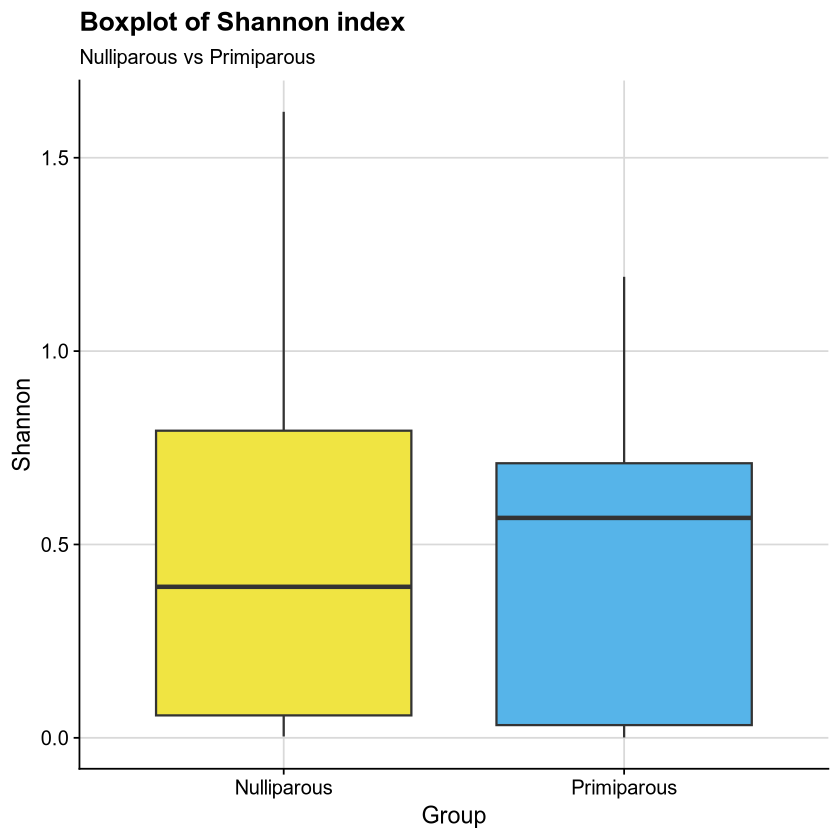

In [28]:
# Choose colors
clr <- c("Nulliparous" = "#F0E442", "Primiparous" = "#56B4E9")

# Boxplot of shannon index
df_shannon |> 
  ggplot(aes(x = Group, y = Shannon, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Shannon index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

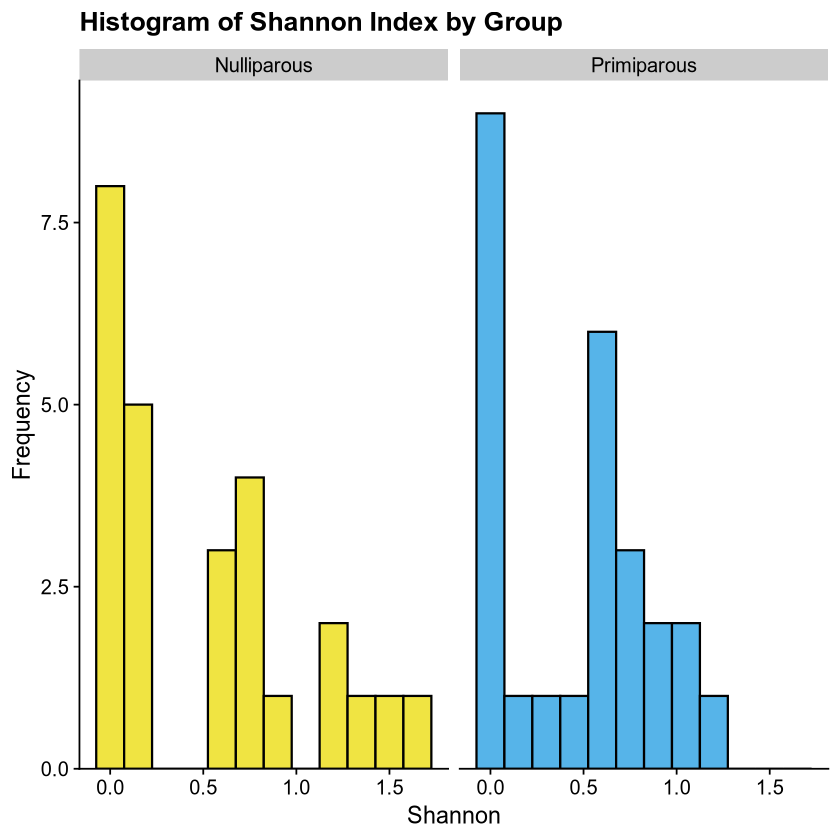

In [29]:
# Histogram of shannon index
df_shannon |> ggplot(aes(x = Shannon, fill = Group)) + 
  geom_histogram(binwidth = 0.15, position = "identity", col = "black") + 
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Shannon Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [30]:
combined_fp_sp_tp1$kit1.vaginal_sample.barcode

[1] "FF02014263" "FF00653507" "FF00653546" "FF02557868" "FB02825409"
 [6] "FF00657534" "FF03817636" "FF02014805" "FF00651927" "FF00652411"
[11] "FF02015815" "FF02014833" "FF00657923" "FF00619356" "FF00653065"
[16] "FF00620268" "FF00653167" "FB02846091" "FF00653014" "FF02015432"
[21] "FF00653071" "FF00652106" "FF02014181" "FF00530208" "FF00657563"
[26] "FF02015345" "FF06039085" "FF00530247" "FF06580399" "FF06039601"
[31] "FF03817982" "FF05043036" "FF06039830" "FF05025300" "FF01570777"
[36] "FF05024757" "FF06040007" "FF05044855" "FF03816924" "FF05043003"
[41] "FF04023664" "FF06039627" "FF06039831" "FF01570782" "FF06039595"
[46] "FF04761460" "FF06032885" "FF06579566" "FF05024953" "FF05024748"
[51] "FF01566745" "FF01571067"

In [31]:
# after this Primiparous == NA
df_shannon_1 <- df_shannon |>
  rownames_to_column(var = "Sample_ID")
head(df_shannon_1)

,Sample_ID,Shannon,Group
,<chr>,<dbl>,<chr>
1,FF00653546,0.13195913,Nulliparous
2,FB02825409,1.29491833,Nulliparous
3,FF02015345,0.79838981,Nulliparous
4,FF00653065,0.08743932,Nulliparous
5,FF02014263,0.00411877,Nulliparous
6,FF02015432,0.78158728,Nulliparous


In [32]:
df_wide_shan <- pivot_wider(df_shannon_1, names_from = Group, values_from = Shannon)

In [33]:
# Extrac personal numbers for barcodes and add new column with pn to df_shannon_1
pn <- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% df_shannon_1$Sample_ID) %>% pull(Q1_Personnummer)
df_shannon_1$Personal_number <- pn
df_shannon_1$Personal_number
head(df_shannon_1)

[1] "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c" "P62ea0b2" "P719b21e"
[13] "P735d77f" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a" "Pa8f3b51"
[19] "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pca94a0f" "Pdab1897"
[25] "Pe706703" "Pf573f67" "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0"
[31] "P3db7da6" "P424fd61" "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c"
[37] "P62ea0b2" "P719b21e" "P735d77f" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c"
[49] "Pca94a0f" "Pdab1897" "Pe706703" "Pf573f67"

,Sample_ID,Shannon,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,FF00653546,0.13195913,Nulliparous,P159f9c8
2,FB02825409,1.29491833,Nulliparous,P1f862a6
3,FF02015345,0.79838981,Nulliparous,P1f95844
4,FF00653065,0.08743932,Nulliparous,P3cac7b0
5,FF02014263,0.00411877,Nulliparous,P3db7da6
6,FF02015432,0.78158728,Nulliparous,P424fd61


In [34]:
# Write to file, name with no space between
#write.csv(df_shannon_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_shannon", ".csv"), row.names = FALSE)

In [35]:
which(duplicated(df_shannon_1$Personal_number) == TRUE)

[1] 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
[26] 52

In [36]:
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 26

In [37]:
shannon_wide <- df_shannon_1 |>
  select(Personal_number, Group, Shannon) |>
  pivot_wider(
    names_from = Group,
    values_from = Shannon
    )
shannon_wide

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.131959129,0.7113538792
P1f862a6,1.294918333,0.0200829490
P1f95844,0.798389810,0.0048036287
P3cac7b0,0.087439322,1.0171530449
P3db7da6,0.004118770,0.5936483883
P424fd61,0.781587279,1.0968878242
P42f2c08,0.724486942,0.0051400790
P4de45e7,0.571581669,0.6628707318
P50f102c,0.089686426,0.0641033645


In [38]:
shannon_wide$difference <- shannon_wide$Primiparous - shannon_wide$Nulliparous
shapiro.test(shannon_wide$difference)
#shannon_wide$difference


	Shapiro-Wilk normality test

data:  shannon_wide$difference
W = 0.95196, p-value = 0.2577


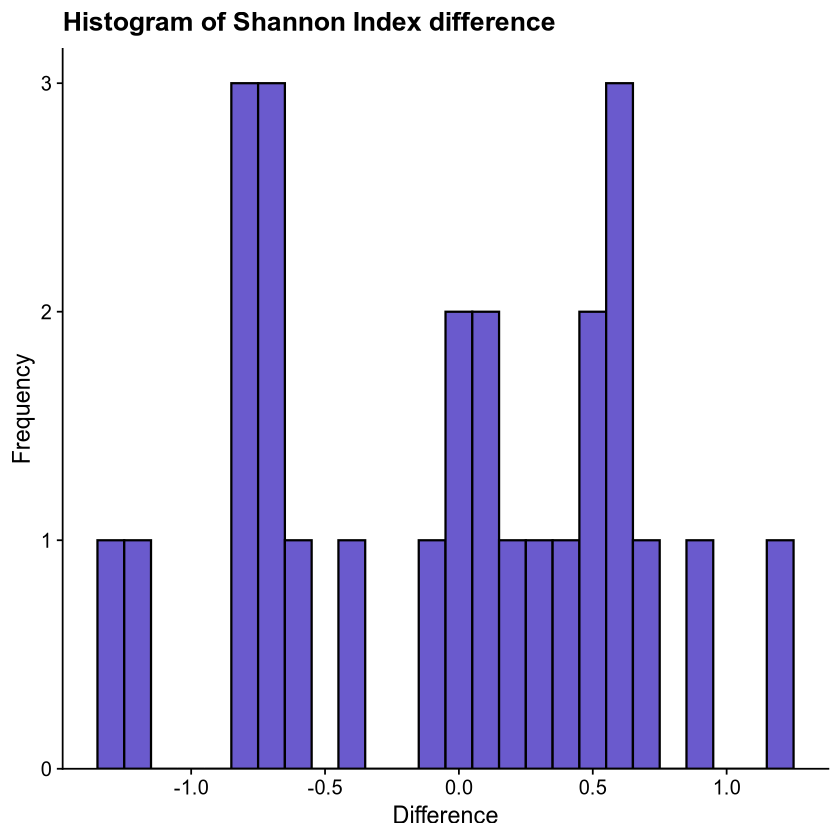

In [39]:
# View the distribution
shannon_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.1, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [40]:
t.test(Pair(Nulliparous, Primiparous) ~ 1,data = shannon_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.43299, df = 25, p-value = 0.6687
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.2166051  0.3319254
sample estimates:
mean difference 
     0.05766011 


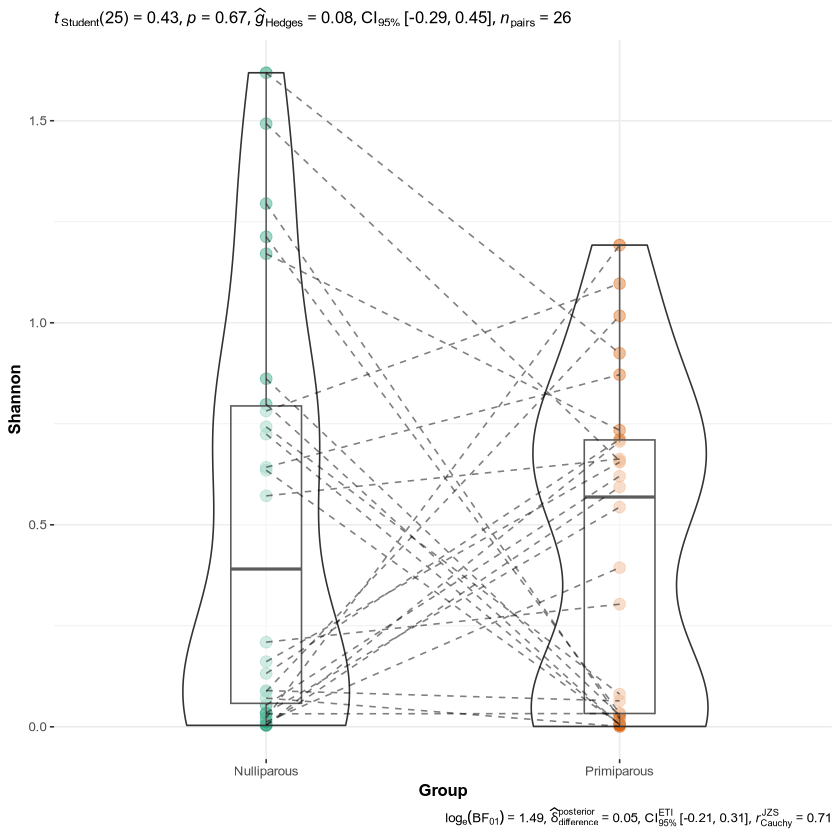

In [41]:
ggwithinstats( # paired samples
  data = df_shannon_1,
  x = Group,
  y = Shannon,
  centrality.plotting = FALSE # remove median
)

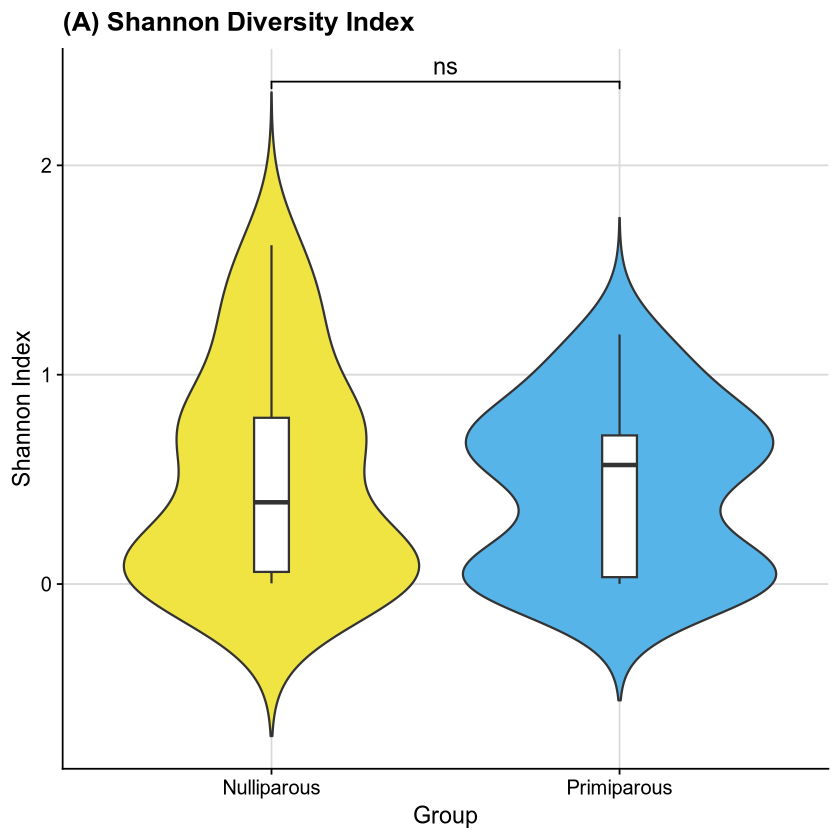

In [42]:
# Shannon Diversity Index Plot
plot_shan <- ggplot(df_shannon, aes(x = Group, y = Shannon, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(title = "(A) Shannon Diversity Index", x = "Group", y = "Shannon Index") +
  theme_half_open() +
  background_grid() +
 theme(legend.position = "none") +
    geom_signif(
    annotations = "ns",                 
    y_position = 2.4,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_shan

## Species richness--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [43]:
# 2 for columns, column = sample
fp_sr <- apply(fp_taxa, 2, specnumber)
head(fp_sr)

FF00653546 FB02825409 FF02015345 FF00653065 FF02014263 FF02015432 
        29         24         17          8          3         37

In [44]:
sp_sr <- apply(sp_taxa, 2, specnumber)
head(sp_sr)

FF01566745 FF06039085 FF06039601 FF06039627 FF03817982 FF05044855 
        10          9          4         16         10         25

In [45]:
summary(fp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.00    7.00   11.50   16.62   28.25   38.00 

In [46]:
summary(sp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3.00    5.25   10.00   11.23   15.75   25.00 

In [47]:
# New df including richness
df_richness <-  data.frame(Species_richness = c(fp_sr, sp_sr), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_sr), length(sp_sr))))
head(df_richness)

,Species_richness,Group
,<int>,<chr>
FF00653546,29,Nulliparous
FB02825409,24,Nulliparous
FF02015345,17,Nulliparous
FF00653065,8,Nulliparous
FF02014263,3,Nulliparous
FF02015432,37,Nulliparous


In [48]:
# Check that num of participants correct
df_richness |> filter(Group == "Nulliparous") |> count()

n
<int>
26


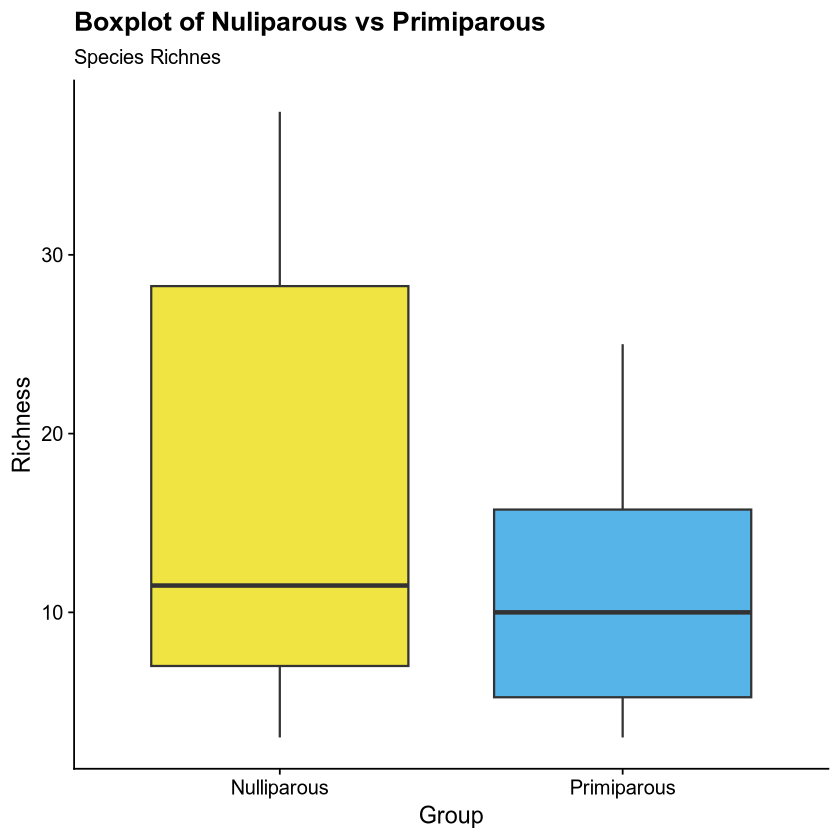

In [49]:
# Boxplot of species richness
df_richness |>
  ggplot(aes(x = Group, y = Species_richness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Richness",
    title = "Boxplot of Nuliparous vs Primiparous",
    subtitle = "Species Richnes"
  ) +
  theme_half_open() +
  theme(legend.position = "none") 

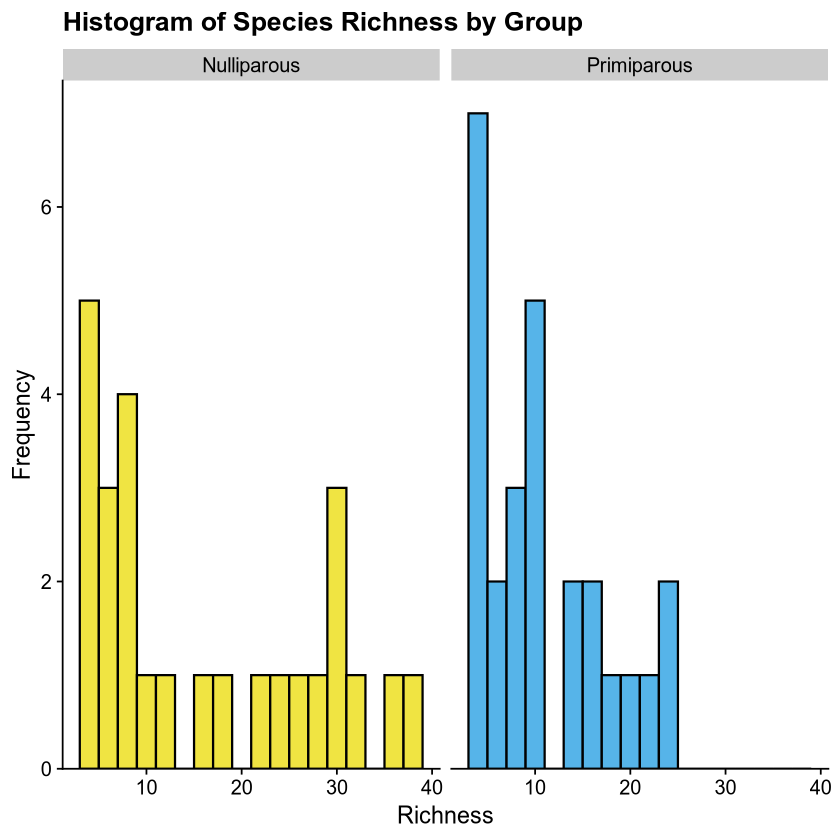

In [50]:
# Histogram of species richness
df_richness |> ggplot(aes(x = Species_richness, fill = Group)) +
  geom_histogram(binwidth = 2, position = "identity", col = "black") +
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Species Richness by Group",
    x = "Richness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [51]:
# Calculate difference for Shapiro test
df_richness_1 <- df_richness |>
  rownames_to_column(var = "Sample_ID")
head(df_richness_1)

,Sample_ID,Species_richness,Group
,<chr>,<int>,<chr>
1,FF00653546,29,Nulliparous
2,FB02825409,24,Nulliparous
3,FF02015345,17,Nulliparous
4,FF00653065,8,Nulliparous
5,FF02014263,3,Nulliparous
6,FF02015432,37,Nulliparous


In [52]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_richness <- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% df_richness_1$Sample_ID) %>% pull(Q1_Personnummer)

In [53]:
# Add column with pn
df_richness_1$Personal_number <- pn_richness
length(df_richness_1$Personal_number)

[1] 52

In [54]:
length(df_richness_1$Personal_number)
head(df_richness_1)

[1] 52

,Sample_ID,Species_richness,Group,Personal_number
,<chr>,<int>,<chr>,<chr>
1,FF00653546,29,Nulliparous,P159f9c8
2,FB02825409,24,Nulliparous,P1f862a6
3,FF02015345,17,Nulliparous,P1f95844
4,FF00653065,8,Nulliparous,P3cac7b0
5,FF02014263,3,Nulliparous,P3db7da6
6,FF02015432,37,Nulliparous,P424fd61


In [55]:
which(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
[26] 52

In [56]:
length(which(duplicated(df_richness_1$Personal_number) == TRUE))

[1] 26

In [57]:
#write.csv(df_richness_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", 
 #                                      Sys.Date(), "_tp1_richness", ".csv"), row.names = FALSE)

In [58]:
richness_wide <- df_richness_1 |>
  select(Personal_number, Group, Species_richness) |>
  pivot_wider(
             names_from = Group,
             values_from = Species_richness
           )

In [59]:
# Test data distribution
richness_wide$difference <- richness_wide$Primiparous - richness_wide$Nulliparous
shapiro.test(richness_wide$difference)


	Shapiro-Wilk normality test

data:  richness_wide$difference
W = 0.94894, p-value = 0.219


In [60]:
head(richness_wide)

Personal_number,Nulliparous,Primiparous,difference
<chr>,<int>,<int>,<int>
P159f9c8,29,10,-19
P1f862a6,24,9,-15
P1f95844,17,4,-13
P3cac7b0,8,16,8
P3db7da6,3,10,7
P424fd61,37,25,-12


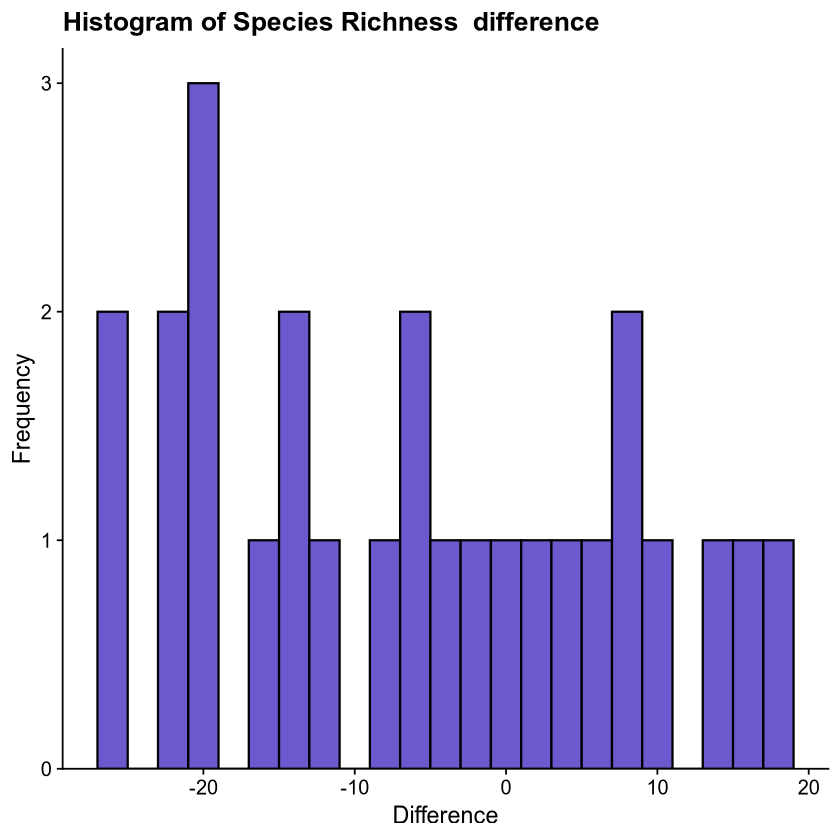

In [61]:
# Data distribution visualization
richness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 2, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Richness  difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [62]:
t.test(Pair(Nulliparous, Primiparous) ~ 1, data = richness_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 2.037, df = 25, p-value = 0.05237
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.05971118 10.82894195
sample estimates:
mean difference 
       5.384615 


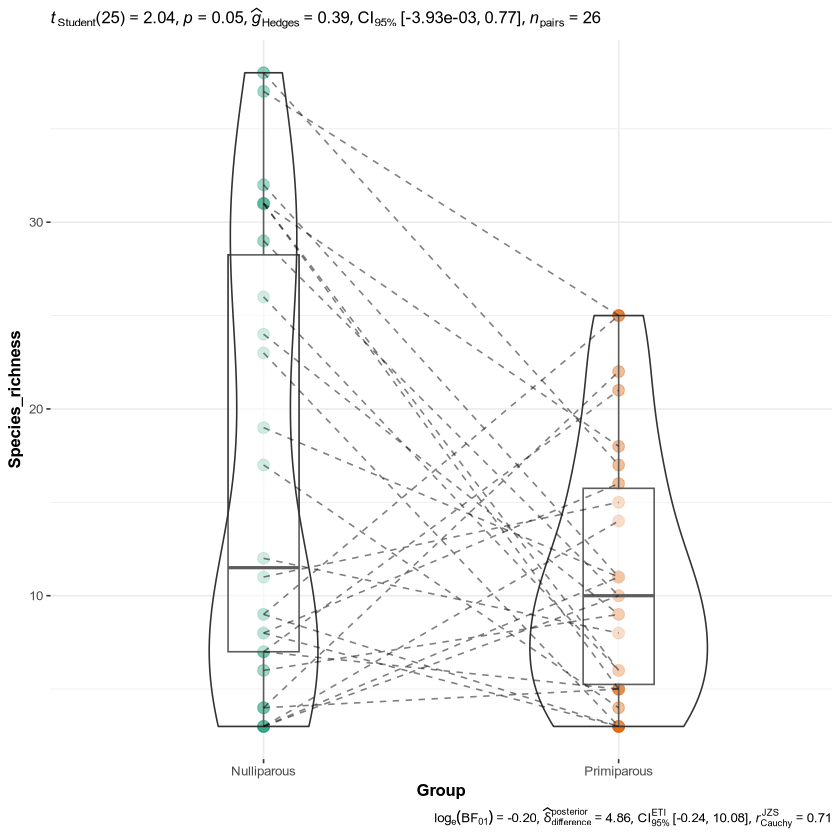

In [63]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_richness,
  x = Group,
  y = Species_richness,
  centrality.plotting = FALSE # remove median
)

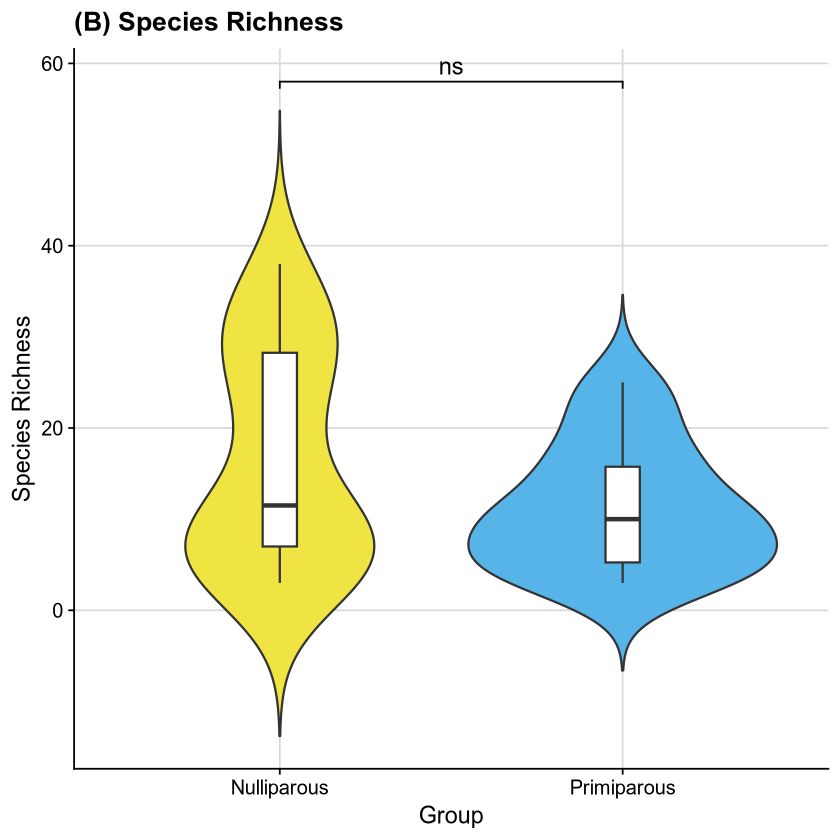

In [64]:
# Shannon Diversity Index Plot
plot_richness <- ggplot(df_richness, aes(x = Group, y = Species_richness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    title = "(B) Species Richness", 
    x = "Group", 
    y = "Species Richness"
    ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 58,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_richness

## Evenness ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [65]:
# Fp
case_pie_small <- fp_shan/log(fp_sr)
case_pie_small

FF00653546  FB02825409  FF02015345  FF00653065  FF02014263  FF02015432 
0.039188457 0.407456387 0.281796573 0.042049425 0.003749066 0.216451135 
 FF00657563  FF00653167  FF02557868  FF02015815  FB02846091  FF00620268 
0.348404573 0.319005803 0.064695081 0.353133594 0.010233084 0.337812833 
 FF00653071  FF00657923  FF02014181  FF03817636  FF00652411  FF02014833 
0.016540171 0.458159257 0.184918063 0.048897852 0.471386613 0.006177844 
 FF00651927  FF00619356  FF00657534  FF00653507  FF00652106  FF00530208 
0.024837969 0.032325828 0.274752601 0.252190897 0.084307739 0.176607298 
 FF02014805  FF00653014 
0.067237639 0.003253998

In [66]:
summary(case_pie_small)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.003254 0.034042 0.130458 0.174060 0.309704 0.471387 

In [67]:
# Sp
control_pie <- sp_shan/log(sp_sr)
control_pie

FF01566745   FF06039085   FF06039601   FF06039627   FF03817982   FF05044855 
0.3089370644 0.0091401440 0.0034650856 0.3668604134 0.2578182192 0.3407673622 
  FF06032885   FF06040007   FF06579566   FF01571067   FF05024757   FF05024748 
0.0046787015 0.3016854711 0.0398296598 0.0208289931 0.3703838301 0.3061023853 
  FF06039595   FF06039831   FF06039830   FF05024953   FF04023664   FF06580399 
0.0203684724 0.3674129519 0.0034451088 0.2587042387 0.3198703918 0.1294151721 
  FF04761460   FF01570782   FF01570777   FF05043003   FF05025300   FF05043036 
0.1759134560 0.0008310368 0.0257109414 0.0336976265 0.1459239970 0.3076012703 
  FF00530247   FF03816924 
0.2418278509 0.2675369447

In [68]:
summary(control_pie)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000831 0.022049 0.208871 0.178029 0.307227 0.370384 

In [69]:
df_evenness <-  data.frame(Evenness = c(case_pie_small, control_pie), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(case_pie_small), length(control_pie))))
head(df_evenness)
class(df_evenness$Evenness)

,Evenness,Group
,<dbl>,<chr>
FF00653546,0.039188457,Nulliparous
FB02825409,0.407456387,Nulliparous
FF02015345,0.281796573,Nulliparous
FF00653065,0.042049425,Nulliparous
FF02014263,0.003749066,Nulliparous
FF02015432,0.216451135,Nulliparous


[1] "numeric"

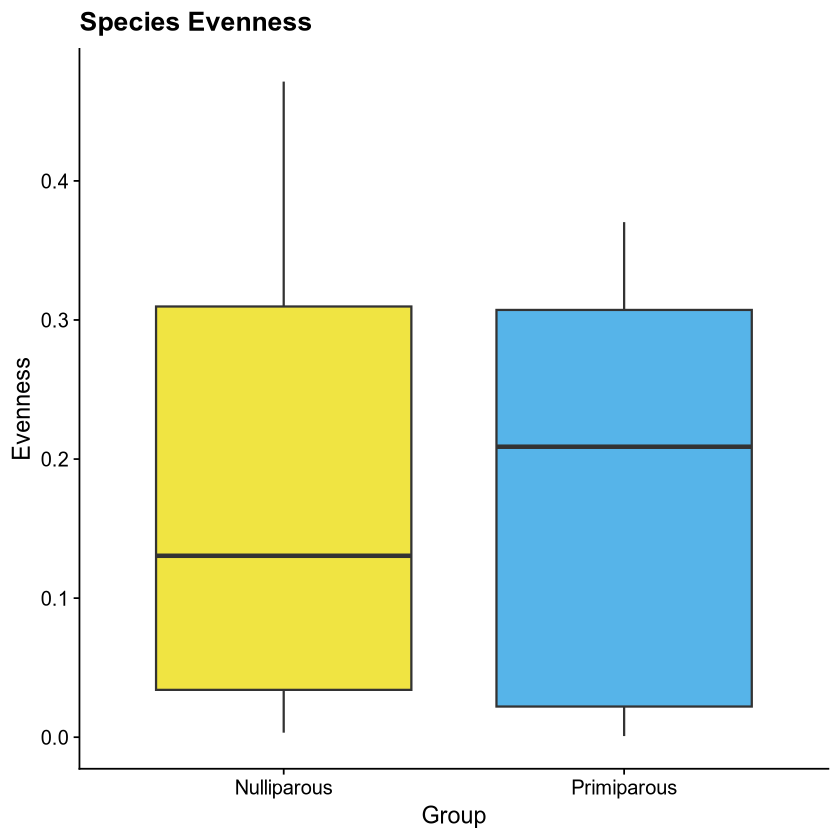

In [70]:
# Boxplot of evenness
df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Evenness",
    title = "Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

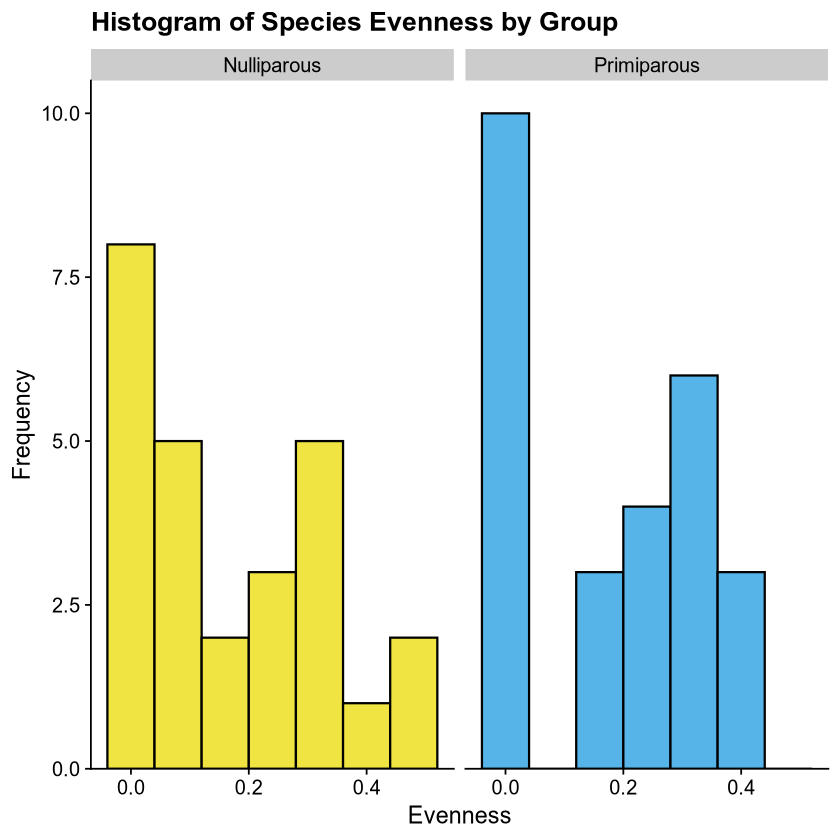

In [71]:
# Histogram of evenness
df_evenness |> ggplot(aes(x = Evenness, fill = Group)) + 
  geom_histogram(binwidth = 0.08, position = "identity", col = "black") + 
  scale_fill_manual(values = clr) +
  labs(
    title = "Histogram of Species Evenness by Group",
    x = "Evenness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [72]:
df_evenness_2 <- df_evenness |>
  rownames_to_column(var = "Sample_ID")
head(df_evenness_2)

,Sample_ID,Evenness,Group
,<chr>,<dbl>,<chr>
1,FF00653546,0.039188457,Nulliparous
2,FB02825409,0.407456387,Nulliparous
3,FF02015345,0.281796573,Nulliparous
4,FF00653065,0.042049425,Nulliparous
5,FF02014263,0.003749066,Nulliparous
6,FF02015432,0.216451135,Nulliparous


In [73]:
# Find and extract pn
pn_evenness <- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% df_evenness_2$Sample_ID) |> pull(Q1_Personnummer)
pn_evenness

[1] "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c" "P62ea0b2" "P719b21e"
[13] "P735d77f" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a" "Pa8f3b51"
[19] "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pca94a0f" "Pdab1897"
[25] "Pe706703" "Pf573f67" "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0"
[31] "P3db7da6" "P424fd61" "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c"
[37] "P62ea0b2" "P719b21e" "P735d77f" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c"
[49] "Pca94a0f" "Pdab1897" "Pe706703" "Pf573f67"

In [74]:
df_evenness_2$Personal_number <- pn_evenness
head(df_evenness_2)
dim(df_evenness_2)

,Sample_ID,Evenness,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,FF00653546,0.039188457,Nulliparous,P159f9c8
2,FB02825409,0.407456387,Nulliparous,P1f862a6
3,FF02015345,0.281796573,Nulliparous,P1f95844
4,FF00653065,0.042049425,Nulliparous,P3cac7b0
5,FF02014263,0.003749066,Nulliparous,P3db7da6
6,FF02015432,0.216451135,Nulliparous,P424fd61


[1] 52  4

In [75]:
#write.csv(df_evenness_2, file = paste0( "/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_evenness", ".csv"), row.names = FALSE)

In [76]:
evenness_wide <- df_evenness_2 |>
  select(Personal_number, Group, Evenness) |>
  pivot_wider(
    names_from = Group,
    values_from = Evenness
  )
head(evenness_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.039188457,0.308937064
P1f862a6,0.407456387,0.009140144
P1f95844,0.281796573,0.003465086
P3cac7b0,0.042049425,0.366860413
P3db7da6,0.003749066,0.257818219
P424fd61,0.216451135,0.340767362


In [77]:
evenness_wide$difference <- evenness_wide$Primiparous - evenness_wide$Nulliparous
shapiro.test(evenness_wide$difference)


	Shapiro-Wilk normality test

data:  evenness_wide$difference
W = 0.95907, p-value = 0.3736


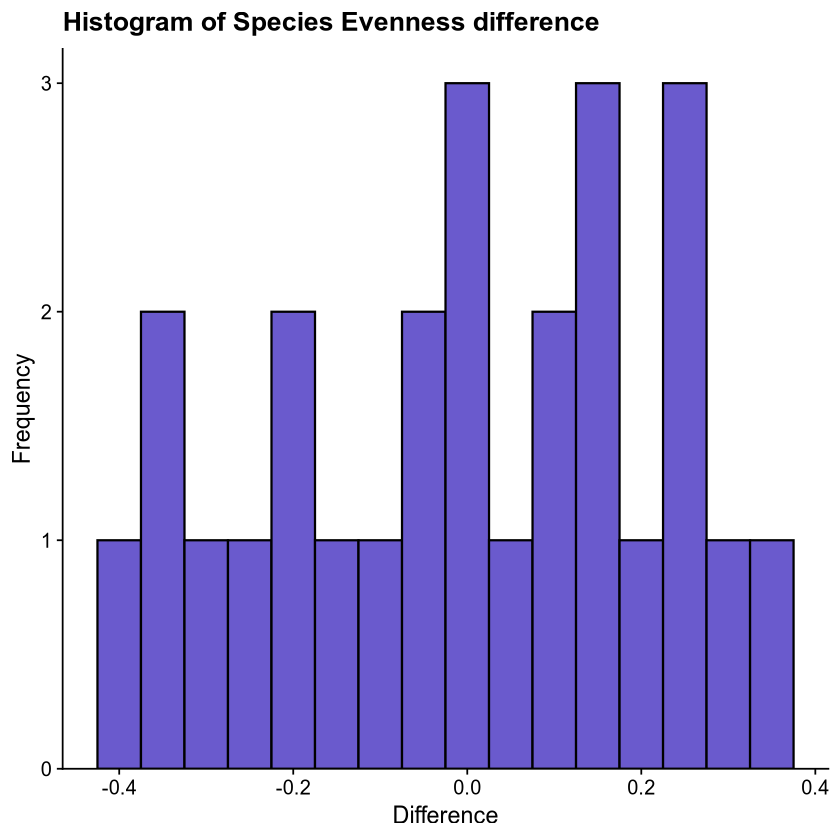

In [78]:
# Visualize data distribution
evenness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.05, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

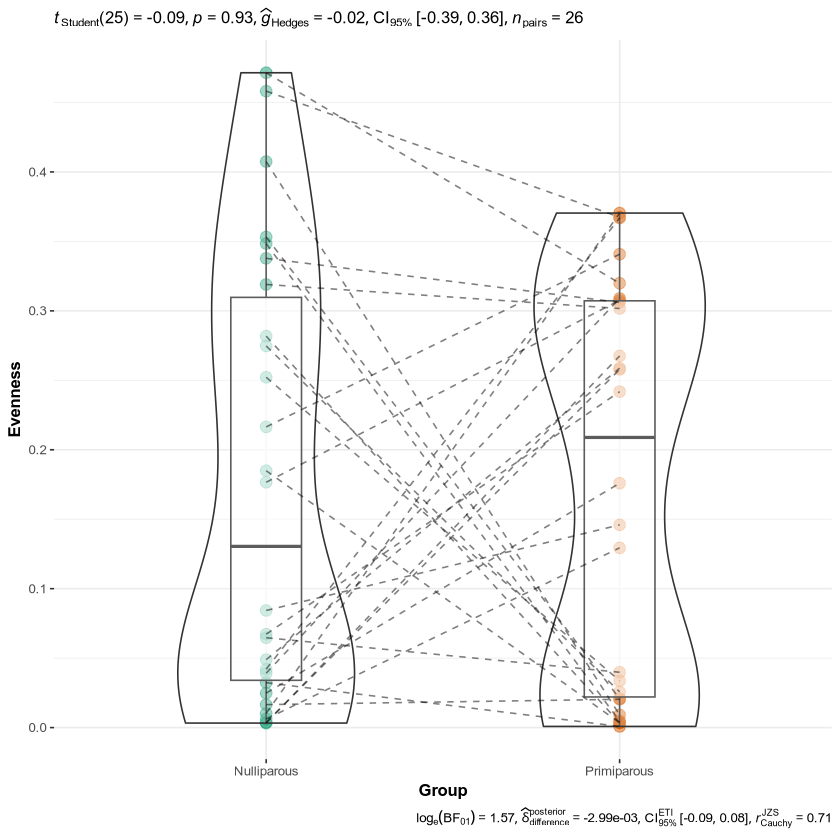

In [79]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_evenness,
  x = Group,
  y = Evenness,
 # type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

In [80]:
test_evenness <- t.test(Pair(Nulliparous, Primiparous) ~1, data = evenness_wide)
test_evenness


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.091145, df = 25, p-value = 0.9281
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.09364733  0.08570987
sample estimates:
mean difference 
   -0.003968731 


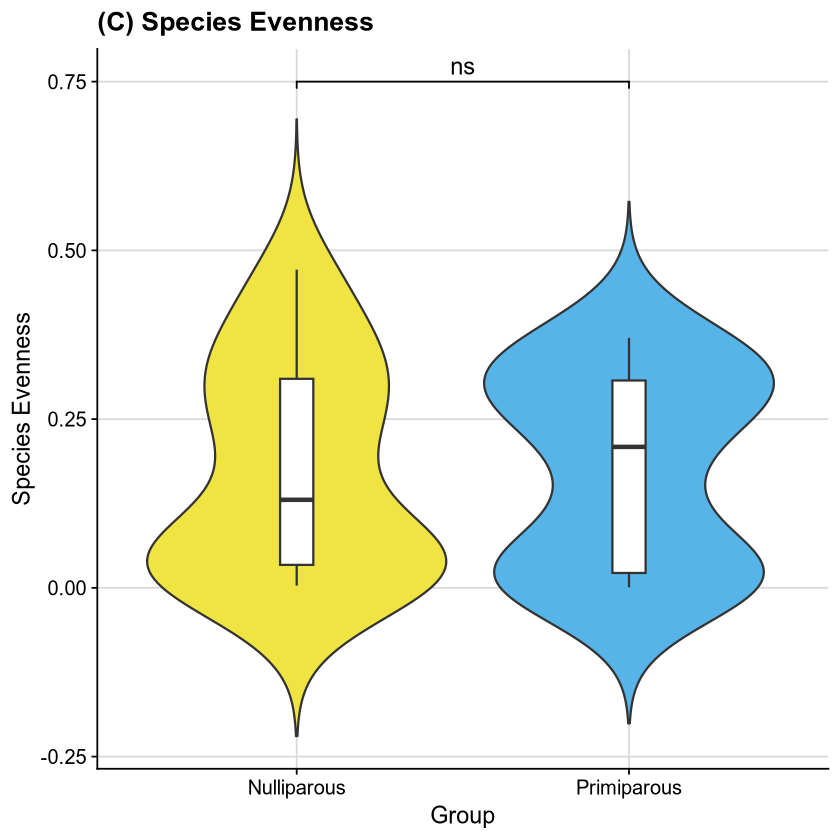

In [81]:
# Violin plots of evenness
plot_evenness <- df_evenness_2 |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Species Evenness",
    title = "(C) Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 0.75,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)
plot_evenness

## Simpson's index---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [82]:
# 2 for columns, column = sample
fp_simpson <- apply(fp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

FF00653546  FB02825409  FF02015345  FF00653065  FF02014263  FF02015432 
0.035194487 0.547372652 0.457256373 0.027936140 0.000877703 0.264161953

In [83]:
sp_simpson <- apply(sp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

FF00653546  FB02825409  FF02015345  FF00653065  FF02014263  FF02015432 
0.035194487 0.547372652 0.457256373 0.027936140 0.000877703 0.264161953

In [84]:
df_simpson <-  data.frame(Simpson = c(fp_simpson, sp_simpson), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_simpson), length(sp_simpson))))
head(df_simpson)
class(df_simpson$Simpson)

,Simpson,Group
,<dbl>,<chr>
FF00653546,0.035194487,Nulliparous
FB02825409,0.547372652,Nulliparous
FF02015345,0.457256373,Nulliparous
FF00653065,0.027936140,Nulliparous
FF02014263,0.000877703,Nulliparous
FF02015432,0.264161953,Nulliparous


[1] "numeric"

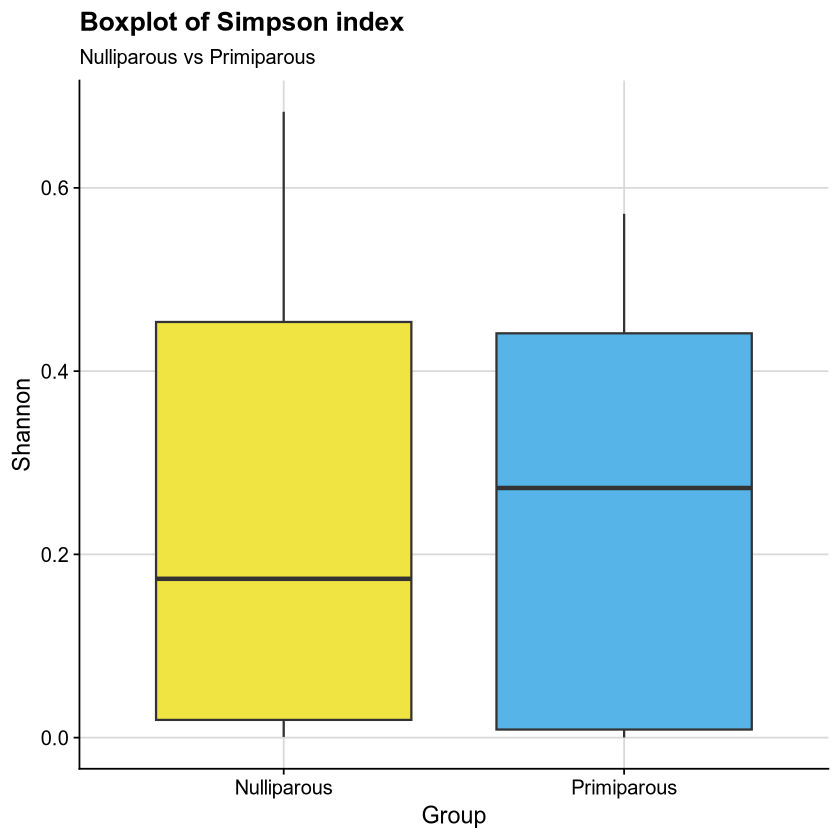

In [85]:
# Boxplot of Simpson index
df_simpson |> 
  ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Simpson index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

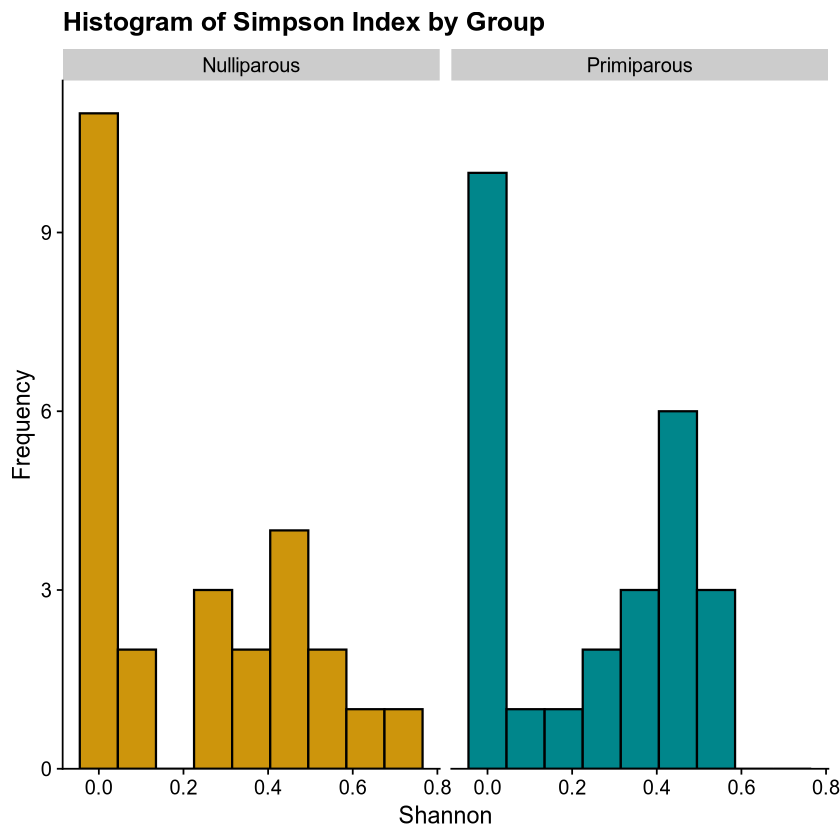

In [86]:
# Histogram of simpson index
df_simpson |> ggplot(aes(x = Simpson, fill = Group)) + 
  geom_histogram(binwidth = 0.09, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Simpson Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [87]:
df_simpson_1 <- df_simpson |>
  rownames_to_column(var = "Sample_ID")
head(df_simpson_1)

,Sample_ID,Simpson,Group
,<chr>,<dbl>,<chr>
1,FF00653546,0.035194487,Nulliparous
2,FB02825409,0.547372652,Nulliparous
3,FF02015345,0.457256373,Nulliparous
4,FF00653065,0.027936140,Nulliparous
5,FF02014263,0.000877703,Nulliparous
6,FF02015432,0.264161953,Nulliparous


In [88]:
# Extrac personal numbers for barcodes and add new column with pn to 
pn_simpson<- combined_fp_sp_tp1 |>
  filter(kit1.vaginal_sample.barcode %in% df_simpson_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_simpson_1$Personal_number <- pn_simpson
df_simpson_1$Personal_number

[1] "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0" "P3db7da6" "P424fd61"
 [7] "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c" "P62ea0b2" "P719b21e"
[13] "P735d77f" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a" "Pa8f3b51"
[19] "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pca94a0f" "Pdab1897"
[25] "Pe706703" "Pf573f67" "P159f9c8" "P1f862a6" "P1f95844" "P3cac7b0"
[31] "P3db7da6" "P424fd61" "P42f2c08" "P4de45e7" "P50f102c" "P5b98b6c"
[37] "P62ea0b2" "P719b21e" "P735d77f" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe04f9f" "Pbe289c8" "Pc44e366" "Pc77a35c"
[49] "Pca94a0f" "Pdab1897" "Pe706703" "Pf573f67"

In [89]:
length(which(duplicated(df_simpson_1$Personal_number) == TRUE))

[1] 26

In [90]:
#write.csv(df_simpson_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/vaginal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_simpson", ".csv"), row.names = FALSE)

In [91]:
simpson_wide <- df_simpson_1 |>
  select(Personal_number, Group, Simpson) |>
  pivot_wider(
             names_from = Group,
             values_from = Simpson
           )
head(simpson_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.035194487,0.465800685
P1f862a6,0.547372652,0.004737051
P1f95844,0.457256373,0.001101025
P3cac7b0,0.027936140,0.418528345
P3db7da6,0.000877703,0.360012179
P424fd61,0.264161953,0.571688145


In [92]:
# Test data distribution
simpson_wide$difference <- simpson_wide$Primiparous - simpson_wide$Nulliparous
shapiro.test(simpson_wide$difference)


	Shapiro-Wilk normality test

data:  simpson_wide$difference
W = 0.93693, p-value = 0.1135


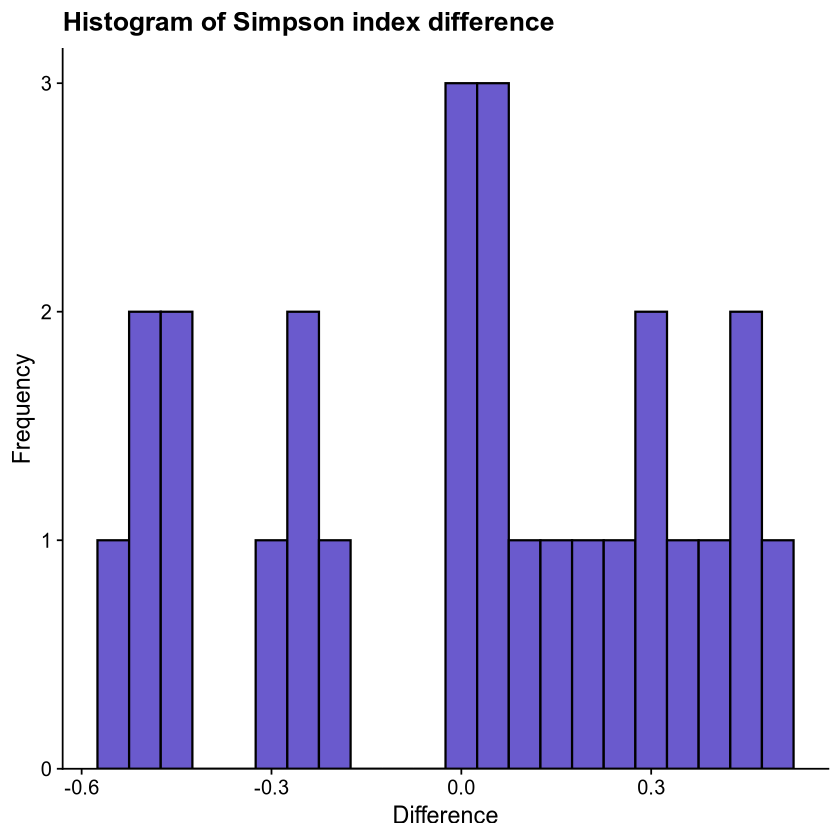

In [93]:
# Data distribution visualization
simpson_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.05, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Simpson index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [94]:
test_simpson <- t.test(Pair(Nulliparous, Primiparous) ~1, data = simpson_wide)
test_simpson


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.065192, df = 25, p-value = 0.9485
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1366491  0.1282637
sample estimates:
mean difference 
   -0.004192709 


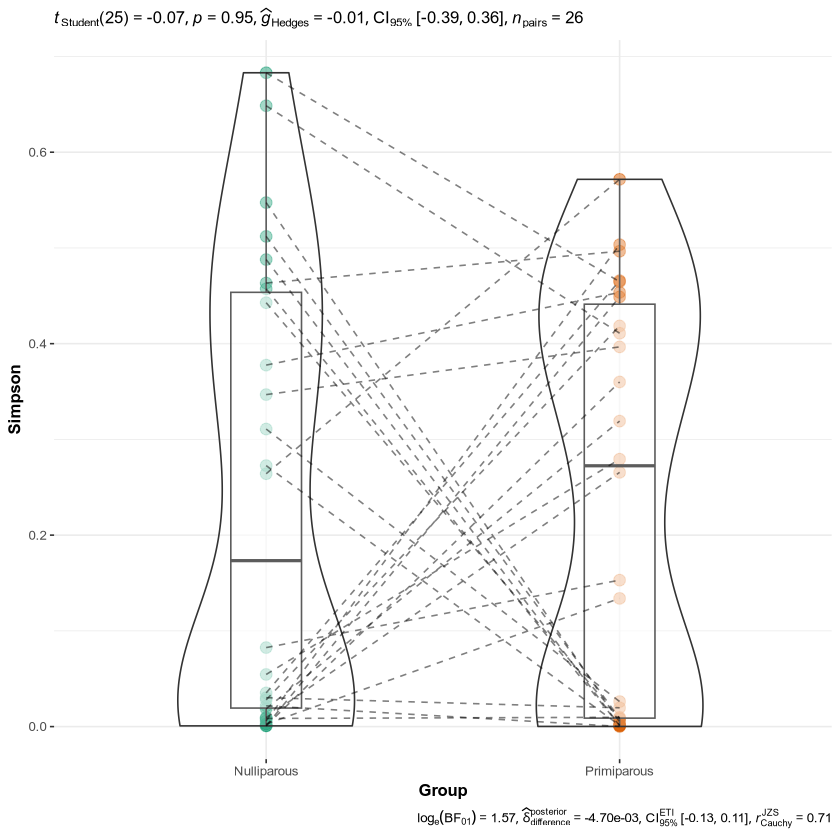

In [95]:
# view the data distribution
ggwithinstats( # paired samples
  data = df_simpson,
  x = Group,
  y = Simpson,
  #type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

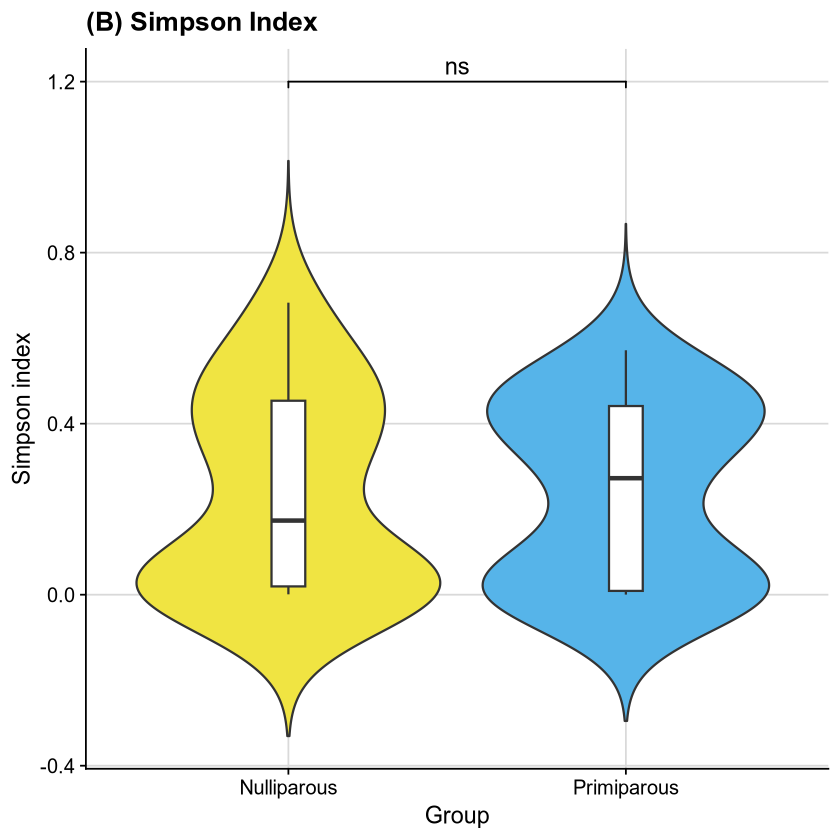

In [96]:
# Violin plots
plot_simpson <- df_simpson |> ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Simpson index",
    title = "(B) Simpson Index"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  theme(legend.position = "none") +
geom_signif(
    annotations = "ns",                 
    y_position = 1.2,                 
    xmin = 1,
    xmax = 2,
    tip_length = 0.02,
    textsize = 5)

plot_simpson

# Combined plot~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [97]:
# remove legends so only one remains
plot_shannon_nl <- plot_shan +  guides(fill = "none", color = "none") 
plot_richness_nl <- plot_richness +  guides(fill = "none", color = "none") 

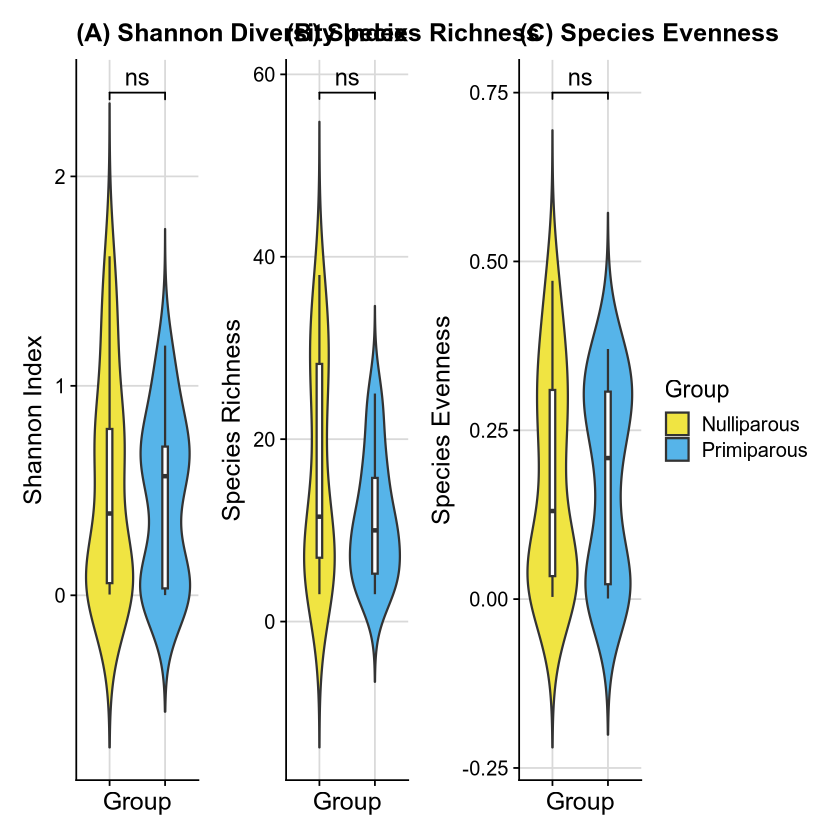

In [98]:
final_plot <-
  ( plot_shannon_nl | plot_richness_nl | plot_evenness) &
  theme_half_open() &
  background_grid() &
  theme(
    axis.text.x = element_blank(), # Remove Nulliparous etc
    plot.title = element_text(size = 15),
    axis.title = element_text(size = 15)
  )

final_plot

In [99]:
#ggsave(file = paste0(Sys.Date(), "_vag_alpha_tp1.pdf"), path ="/ceph/projects/010_SweMaMi/bm.nowak/plot_output/", 
 #      plot = final_plot, width = 14, height = 8)